### **Power analysis**

**Effect size assumptions:**
- H1 (AI Benefit): ~7pp accuracy improvement with AI assistance, based on Green & Chen (2019)
- H3 (Timing Effect): 4pp difference in mean probability distance from AI, d ≈ 0.3 (conservative)
- Within-subject design: each participant contributes to all conditions

**Key insight:** Binary accuracy (correct/incorrect) is the lowest-powered outcome. 
The probability slider provides a continuous measure that is far more sensitive to protocol effects.
H3 is tested primarily on the continuous probability distance measure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit

np.random.seed(42)

In [2]:
N_SIMS = 500
SAMPLE_SIZES = [50, 75, 100, 125, 150, 200]
N_CASES = 18
N_AI_CASES = 12  # cases per participant with AI (2 blocks of 6)

# H1: AI benefit on binary accuracy
#   No-AI baseline ~65% accuracy, AI conditions ~72%
#   = 0.3 log-odds, based on Green & Chen (2019) finding ~5-8pp improvement
INTERCEPT = 0.6           # ~65% no-AI accuracy
AI_BENEFIT = 0.3          # log-odds increase with AI

# H3: Timing effect on continuous probability distance
#   AI-first: participants anchor closer to AI prediction (mean distance ~8pp)
#   Human-first: participants maintain more independence (mean distance ~12pp)
#   Effect size d ≈ 0.3 (conservative, based on anchoring literature)
MEAN_DIST_AI_FIRST = 0.08    # mean |participant_prob - model_prob|
MEAN_DIST_HUMAN_FIRST = 0.12
SD_DIST = 0.10               # within-condition SD

In [3]:
results = []

for n in SAMPLE_SIZES:
    sig_h1 = 0
    sig_h3_continuous = 0
    sig_h3_binary = 0
    
    for sim in range(N_SIMS):
        # --- H1: Binary accuracy, AI vs No-AI ---
        # Each participant: 6 no-AI trials, 12 AI trials
        no_ai_correct = np.random.binomial(6, expit(INTERCEPT), size=n)
        ai_correct = np.random.binomial(12, expit(INTERCEPT + AI_BENEFIT), size=n)
        
        # Participant-level accuracy rates
        no_ai_rate = no_ai_correct / 6
        ai_rate = ai_correct / 12
        
        # Paired t-test (participant is own control)
        t_h1, p_h1 = stats.ttest_rel(ai_rate, no_ai_rate)
        if p_h1 < 0.05 and t_h1 > 0:
            sig_h1 += 1
        
        # --- H3: Continuous probability distance ---
        # AI-first block: 6 trials per participant
        # Human-first block: 6 trials per participant
        ai_first_distances = np.abs(
            np.random.normal(MEAN_DIST_AI_FIRST, SD_DIST, size=(n, 6))
        )
        human_first_distances = np.abs(
            np.random.normal(MEAN_DIST_HUMAN_FIRST, SD_DIST, size=(n, 6))
        )
        
        # Participant-level means
        ai_first_mean = ai_first_distances.mean(axis=1)
        human_first_mean = human_first_distances.mean(axis=1)
        
        # Paired t-test on continuous measure
        t_h3c, p_h3c = stats.ttest_rel(human_first_mean, ai_first_mean)
        if p_h3c < 0.05:
            sig_h3_continuous += 1
        
        # H3 on binary accuracy (for comparison)
        ai_first_correct = np.random.binomial(6, expit(INTERCEPT + AI_BENEFIT), size=n)
        human_first_correct = np.random.binomial(
            6, expit(INTERCEPT + AI_BENEFIT + 0.15), size=n
        )
        ai_first_rate = ai_first_correct / 6
        human_first_rate = human_first_correct / 6
        t_h3b, p_h3b = stats.ttest_rel(human_first_rate, ai_first_rate)
        if p_h3b < 0.05:
            sig_h3_binary += 1
    
    results.append({
        'n': n,
        'power_h1_binary': sig_h1 / N_SIMS,
        'power_h3_continuous': sig_h3_continuous / N_SIMS,
        'power_h3_binary': sig_h3_binary / N_SIMS,
    })
    print(f"N={n:>3d}: H1(binary)={sig_h1/N_SIMS:.2f}  "
          f"H3(continuous)={sig_h3_continuous/N_SIMS:.2f}  "
          f"H3(binary)={sig_h3_binary/N_SIMS:.2f}")

power_df = pd.DataFrame(results)

N= 50: H1(binary)=0.47  H3(continuous)=0.97  H3(binary)=0.10
N= 75: H1(binary)=0.66  H3(continuous)=0.99  H3(binary)=0.19
N=100: H1(binary)=0.79  H3(continuous)=1.00  H3(binary)=0.19
N=125: H1(binary)=0.87  H3(continuous)=1.00  H3(binary)=0.23
N=150: H1(binary)=0.93  H3(continuous)=1.00  H3(binary)=0.30
N=200: H1(binary)=0.97  H3(continuous)=1.00  H3(binary)=0.40


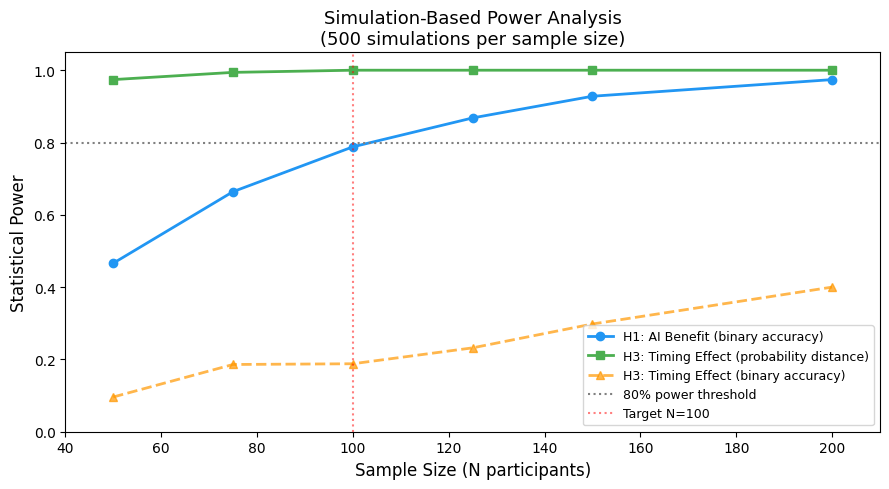


=== POWER ANALYSIS SUMMARY ===

  n  power_h1_binary  power_h3_continuous  power_h3_binary
 50            0.466                0.974            0.096
 75            0.664                0.994            0.186
100            0.788                1.000            0.188
125            0.868                1.000            0.232
150            0.928                1.000            0.298
200            0.974                1.000            0.400

At N=100:
  H1 (binary accuracy):        0.79
  H3 (probability distance):   1.00
  H3 (binary accuracy):        0.19

Conclusion: H3 should be tested primarily on continuous probability
distance, with binary accuracy as a secondary analysis.


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(power_df['n'], power_df['power_h1_binary'], 'o-', 
        label='H1: AI Benefit (binary accuracy)', linewidth=2, color='#2196F3')
ax.plot(power_df['n'], power_df['power_h3_continuous'], 's-', 
        label='H3: Timing Effect (probability distance)', linewidth=2, color='#4CAF50')
ax.plot(power_df['n'], power_df['power_h3_binary'], '^--', 
        label='H3: Timing Effect (binary accuracy)', linewidth=2, color='#FF9800', alpha=0.7)
ax.axhline(0.80, color='gray', linestyle=':', label='80% power threshold')
ax.axvline(100, color='red', linestyle=':', alpha=0.5, label='Target N=100')
ax.set_xlabel('Sample Size (N participants)', fontsize=12)
ax.set_ylabel('Statistical Power', fontsize=12)
ax.set_title('Simulation-Based Power Analysis\n(500 simulations per sample size)', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 1.05)
ax.set_xlim(40, 210)
plt.tight_layout()
plt.savefig("../visualizations/power_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\n=== POWER ANALYSIS SUMMARY ===\n")
print(power_df.to_string(index=False))
print(f"\nAt N=100:")
row = power_df[power_df['n'] == 100].iloc[0]
print(f"  H1 (binary accuracy):        {row['power_h1_binary']:.2f}")
print(f"  H3 (probability distance):   {row['power_h3_continuous']:.2f}")
print(f"  H3 (binary accuracy):        {row['power_h3_binary']:.2f}")
print(f"\nConclusion: H3 should be tested primarily on continuous probability")
print(f"distance, with binary accuracy as a secondary analysis.")